In [ ]:
# ── CUDA DLL preloader ── Run this cell BEFORE any TF import ──────────────
import ctypes, os

cuda_path = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
_dlls = [
    "cublas64_11.dll", "cublasLt64_11.dll", "cudart64_110.dll",
    "cudnn64_8.dll",   "cufft64_10.dll",    "curand64_10.dll",
    "cusolver64_11.dll", "cusparse64_11.dll",
]
for _dll in _dlls:
    _p = os.path.join(cuda_path, _dll)
    if os.path.exists(_p):
        try:
            ctypes.WinDLL(_p)
        except Exception as e:
            print(f"Warning: could not load {_dll}: {e}")
print("CUDA DLLs preloaded.")

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import gc
import pickle
from tensorflow.keras.layers import Activation, Flatten, Dense, Reshape, Input, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot, Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
import warnings
from PIL import Image
from tensorflow.keras.utils import to_categorical
import wandb
from wandb.keras import WandbCallback

# TF / Keras sub-imports used by DualPathNetwork
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras.layers import concatenate, add, BatchNormalization, LayerNormalization
from keras.layers import Input as KInput
from keras.regularizers import l2
from tensorflow.keras.utils import get_source_inputs
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import keras.backend as K

# ── GPU memory growth ──────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs available: {[g.name for g in gpus]}")
else:
    print("No GPU found – running on CPU")

# ── _obtain_input_shape shim (replaces keras_applications) ────────────────
def _obtain_input_shape(input_shape, default_size, min_size, data_format,
                        require_flatten, weights=None):
    if input_shape is not None:
        return input_shape
    if require_flatten:
        if data_format == 'channels_last':
            return (default_size, default_size, 3)
        return (3, default_size, default_size)
    return None

2024-05-14 09:39:53.292812: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-14 09:39:53.292905: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-14 09:39:53.387760: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for class_label, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            img = Image.open(img_path)
            img = img.resize((64, 64))
            img = np.array(img)
            if img is not None:
                images.append(img)
                labels.append(class_label)
    return np.array(images), np.array(labels)

# Local dataset path (was: /kaggle/input/paddydoctormedium)
dataset_folder = r'E:\PaddyDoctor\PaddyDoctor\paddy_doctor_medium'

x_data, y_data = load_images_from_folder(dataset_folder)

random_indices = np.random.permutation(len(x_data))
x_data = x_data[random_indices]
y_data = y_data[random_indices]

split_idx = int(0.8 * len(x_data))
x_train, x_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Flatten for SMOTE
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test  = x_test.reshape((len(x_test),  np.prod(x_test.shape[1:])))

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data generator with augmentation options
datagen = ImageDataGenerator(
    rotation_range=20,      # Random rotation in the range [-20, 20] degrees
    width_shift_range=0.1,  # Random horizontal shift by 10% of the width
    height_shift_range=0.1, # Random vertical shift by 10% of the height
    shear_range=0.2,        # Shear intensity (shear angle in radians)
    zoom_range=0.2,         # Random zoom by 20%
    horizontal_flip=True,   # Random horizontal flip
    fill_mode='nearest'     # Fill mode for points outside the input boundaries
)

In [6]:
x_train = x_train.reshape(-1, 64, 64, 3)

In [7]:
datagen.fit(x_train)

# Example of using the data generator to augment data during training
augmented_data_generator = datagen.flow(x_train, y_train, batch_size=32)

In [8]:
x_train = x_train.reshape(x_train.shape[0],-1)

In [9]:
borderline_smote = SMOTE(random_state=42)
x_train_bls, y_train_bls = borderline_smote.fit_resample(x_train, y_train)

In [ ]:
# Data already normalized in the loading cell – just ensure correct dtype
x_train_bls = x_train_bls.astype('float32')
x_test      = x_test.astype('float32')

In [11]:
num_classes = len(np.unique(y_train_bls))
y_train_one_hot = to_categorical(y_train_bls, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

In [12]:
x_train_bls = x_train_bls.reshape(-1, 64, 64, 3)
x_test = x_test.reshape(-1, 64, 64, 3)


# Dual-Path Networks


In [13]:
__all__ = ['DualPathNetwork', 'DPN92', 'DPN98', 'DPN137', 'DPN107', 'preprocess_input', 'decode_predictions']


def preprocess_input(x, data_format=None):
    """Preprocesses a tensor encoding a batch of images.
       Obtained from https://github.com/cypw/DPNs

        # Arguments
            x: input Numpy tensor, 4D.
            data_format: data format of the image tensor.

        # Returns
            Preprocessed tensor.
        """
    if data_format is None:
        data_format = K.image_data_format()
    assert data_format in {'channels_last', 'channels_first'}

    if data_format == 'channels_first':
        # 'RGB'->'BGR'
        x = x[:, ::-1, :, :]
        # Zero-center by mean pixel
        x[:, 0, :, :] -= 104
        x[:, 1, :, :] -= 117
        x[:, 2, :, :] -= 128
    else:
        # 'RGB'->'BGR'
        x = x[:, :, :, ::-1]
        # Zero-center by mean pixel
        x[:, :, :, 0] -= 104
        x[:, :, :, 1] -= 117
        x[:, :, :, 2] -= 124

    x *= 0.0167
    return x


def DualPathNetwork(input_shape=None,
                    initial_conv_filters=64,
                    depth=[3, 4, 20, 3],
                    filter_increment=[16, 32, 24, 128],
                    cardinality=32,
                    width=3,
                    weight_decay=0,
                    include_top=True,
                    weights=None,
                    input_tensor=None,
                    pooling=None,
                    classes=1000):
    """ Instantiate the Dual Path Network architecture for the ImageNet dataset. Note that ,
        when using TensorFlow for best performance you should set
        `image_data_format="channels_last"` in your Keras config
        at ~/.keras/keras.json.
        The model are compatible with both
        TensorFlow and Theano. The dimension ordering
        convention used by the model is the one
        specified in your Keras config file.
        # Arguments
            initial_conv_filters: number of features for the initial convolution
            depth: number or layers in the each block, defined as a list.
                DPN-92  = [3, 4, 20, 3]
                DPN-98  = [3, 6, 20, 3]
                DPN-131 = [4, 8, 28, 3]
                DPN-107 = [4, 8, 20, 3]
            filter_increment: number of filters incremented per block, defined as a list.
                DPN-92  = [16, 32, 24, 128]
                DON-98  = [16, 32, 32, 128]
                DPN-131 = [16, 32, 32, 128]
                DPN-107 = [20, 64, 64, 128]
            cardinality: the size of the set of transformations
            width: width multiplier for the network
            weight_decay: weight decay (l2 norm)
            include_top: whether to include the fully-connected
                layer at the top of the network.
            weights: `None` (random initialization) or `imagenet` (trained
                on ImageNet)
            input_tensor: optional Keras tensor (i.e. output of `layers.Input()`)
                to use as image input for the model.
            input_shape: optional shape tuple, only to be specified
                if `include_top` is False (otherwise the input shape
                has to be `(224, 224, 3)` (with `tf` dim ordering)
                or `(3, 224, 224)` (with `th` dim ordering).
                It should have exactly 3 inputs channels,
                and width and height should be no smaller than 8.
                E.g. `(200, 200, 3)` would be one valid value.
            pooling: Optional pooling mode for feature extraction
                when `include_top` is `False`.
                - `None` means that the output of the model will be
                    the 4D tensor output of the
                    last convolutional layer.
                - `avg` means that global average pooling
                    will be applied to the output of the
                    last convolutional layer, and thus
                    the output of the model will be a 2D tensor.
                - `max` means that global max pooling will
                    be applied.
                - `max-avg` means that both global average and global max
                    pooling will be applied to the output of the last
                    convolution layer
            classes: optional number of classes to classify images
                into, only to be specified if `include_top` is True, and
                if no `weights` argument is specified.
        # Returns
            A Keras model instance.
        """

    if weights not in {'imagenet', None}:
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization) or `imagenet` '
                         '(pre-training on ImageNet).')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as imagenet with `include_top`'
                         ' as true, `classes` should be 1000')

    assert len(depth) == len(filter_increment), "The length of filter increment list must match the length " \
                                                "of the depth list."

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _create_dpn(classes, img_input, include_top, initial_conv_filters,
                    filter_increment, depth, cardinality, width, weight_decay, pooling)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input
    # Create model.
    model = Model(inputs, x, name='resnext')

    # load weights

    return model


def DPN92(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN98(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=96, depth=[3, 6, 20, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN137(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 28, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN107(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 20, 3], filter_increment=[20, 64, 64, 128],
                           cardinality=50, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def _initial_conv_block_inception(input, initial_conv_filters, weight_decay=5e-4):
    ''' Adds an initial conv block, with batch norm and relu for the DPN
    Args:
        input: input tensor
        initial_conv_filters: number of filters for initial conv block
        weight_decay: weight decay factor
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(initial_conv_filters, (7, 7), padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=(2, 2))(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    return x


def _bn_relu_conv_block(input, filters, kernel=(3, 3), stride=(1, 1), weight_decay=5e-4):
    ''' Adds a Batchnorm-Relu-Conv block for DPN
    Args:
        input: input tensor
        filters: number of output filters
        kernel: convolution kernel size
        stride: stride of convolution
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(filters, kernel, padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=stride)(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)
    return x


def _grouped_convolution_block(input, grouped_channels, cardinality, strides, weight_decay=5e-4):
    ''' Adds a grouped convolution block. It is an equivalent block from the paper
    Args:
        input: input tensor
        grouped_channels: grouped number of filters
        cardinality: cardinality factor describing the number of groups
        strides: performs strided convolution for downscaling if > 1
        weight_decay: weight decay term
    Returns: a keras tensor
    '''
    init = input
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    group_list = []

    if cardinality == 1:
        # with cardinality 1, it is a standard convolution
        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(init)
        x = BatchNormalization(axis=channel_axis)(x)
        x = Activation('relu')(x)
        return x

    for c in range(cardinality):
        x = Lambda(lambda z: z[:, :, :, c * grouped_channels:(c + 1) * grouped_channels]
                   if K.image_data_format() == 'channels_last' else
                   lambda z: z[:, c * grouped_channels:(c + 1) * grouped_channels, :, :])(input)

        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(x)

        group_list.append(x)

    group_merge = concatenate(group_list, axis=channel_axis)
    group_merge = BatchNormalization(axis=channel_axis)(group_merge)
    group_merge = Activation('relu')(group_merge)
    return group_merge


def _dual_path_block(input, pointwise_filters_a, grouped_conv_filters_b, pointwise_filters_c,
                     filter_increment, cardinality, block_type='normal'):
    '''
    Creates a Dual Path Block. The first path is a ResNeXt type
    grouped convolution block. The second is a DenseNet type dense
    convolution block.

    Args:
        input: input tensor
        pointwise_filters_a: number of filters for the bottleneck
            pointwise convolution
        grouped_conv_filters_b: number of filters for the grouped
            convolution block
        pointwise_filters_c: number of filters for the bottleneck
            convolution block
        filter_increment: number of filters that will be added
        cardinality: cardinality factor
        block_type: determines what action the block will perform
            - `projection`: adds a projection connection
            - `downsample`: downsamples the spatial resolution
            - `normal`    : simple adds a dual path connection

    Returns: a list of two output tensors - one path of ResNeXt
        and another path for DenseNet

    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    grouped_channels = int(grouped_conv_filters_b / cardinality)

    init = concatenate(input, axis=channel_axis) if isinstance(input, list) else input

    if block_type == 'projection':
        stride = (1, 1)
        projection = True
    elif block_type == 'downsample':
        stride = (2, 2)
        projection = True
    elif block_type == 'normal':
        stride = (1, 1)
        projection = False
    else:
        raise ValueError('`block_type` must be one of ["projection", "downsample", "normal"]. Given %s' % block_type)

    if projection:
        projection_path = _bn_relu_conv_block(init, filters=pointwise_filters_c + 2 * filter_increment,
                                              kernel=(1, 1), stride=stride)
        input_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                     if K.image_data_format() == 'channels_last' else
                                     z[:, :pointwise_filters_c, :, :])(projection_path)
        input_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, pointwise_filters_c:, :, :])(projection_path)
    else:
        input_residual_path = input[0]
        input_dense_path = input[1]

    x = _bn_relu_conv_block(init, filters=pointwise_filters_a, kernel=(1, 1))
    x = _grouped_convolution_block(x, grouped_channels=grouped_channels, cardinality=cardinality, strides=stride)
    x = _bn_relu_conv_block(x, filters=pointwise_filters_c + filter_increment, kernel=(1, 1))

    output_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, :pointwise_filters_c, :, :])(x)
    output_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                               if K.image_data_format() == 'channels_last' else
                               z[:, pointwise_filters_c:, :, :])(x)

    residual_path = add([input_residual_path, output_residual_path])
    dense_path = concatenate([input_dense_path, output_dense_path], axis=channel_axis)

    return [residual_path, dense_path]


def _create_dpn(nb_classes, img_input, include_top, initial_conv_filters,
                filter_increment, depth, cardinality=32, width=3, weight_decay=5e-4, pooling=None):
    ''' Creates a ResNeXt model with specified parameters
    Args:
        initial_conv_filters: number of features for the initial convolution
        include_top: Flag to include the last dense layer
        initial_conv_filters: number of features for the initial convolution
        filter_increment: number of filters incremented per block, defined as a list.
            DPN-92  = [16, 32, 24, 128]
            DON-98  = [16, 32, 32, 128]
            DPN-131 = [16, 32, 32, 128]
            DPN-107 = [20, 64, 64, 128]
        depth: number or layers in the each block, defined as a list.
            DPN-92  = [3, 4, 20, 3]
            DPN-98  = [3, 6, 20, 3]
            DPN-131 = [4, 8, 28, 3]
            DPN-107 = [4, 8, 20, 3]
        width: width multiplier for network
        weight_decay: weight_decay (l2 norm)
        pooling: Optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
            - `max-avg` means that both global average and global max
                pooling will be applied to the output of the last
                convolution layer
    Returns: a Keras Model
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    N = list(depth)
    base_filters = 256

    # block 1 (initial conv block)
    x = _initial_conv_block_inception(img_input, initial_conv_filters, weight_decay)

    # block 2 (projection block)
    filter_inc = filter_increment[0]
    filters = int(cardinality * width)

    x = _dual_path_block(x, pointwise_filters_a=filters,
                         grouped_conv_filters_b=filters,
                         pointwise_filters_c=base_filters,
                         filter_increment=filter_inc,
                         cardinality=cardinality,
                         block_type='projection')

    for i in range(N[0] - 1):
        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='normal')

    # remaining blocks
    for k in range(1, len(N)):
        print("BLOCK %d" % (k + 1))
        filter_inc = filter_increment[k]
        filters *= 2
        base_filters *= 2

        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='downsample')

        for i in range(N[k] - 1):
            x = _dual_path_block(x, pointwise_filters_a=filters,
                                 grouped_conv_filters_b=filters,
                                 pointwise_filters_c=base_filters,
                                 filter_increment=filter_inc,
                                 cardinality=cardinality,
                                 block_type='normal')

    x = concatenate(x, axis=channel_axis)

    if include_top:
        avg = GlobalAveragePooling2D()(x)
        max = GlobalMaxPooling2D()(x)
        x = add([avg, max])
        x = Lambda(lambda z: 0.5 * z)(x)
        x = Dense(nb_classes, use_bias=False, kernel_regularizer=l2(weight_decay),
                  kernel_initializer='he_normal', activation='softmax')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D()(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D()(x)
        elif pooling == 'max-avg':
            a = GlobalMaxPooling2D()(x)
            b = GlobalAveragePooling2D()(x)
            x = add([a, b])
            x = Lambda(lambda z: 0.5 * z)(x)

    return x

if __name__ == '__main__':
    model = DPN92((224, 224, 3))


BLOCK 2
BLOCK 3
BLOCK 4


In [14]:
from keras.models import Sequential

In [15]:
model4 = DPN92(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),classes=13)
model4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

BLOCK 2
BLOCK 3
BLOCK 4


In [16]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.88:
            self.model.stop_training = True

# Instantiate the custom callback
callback1 = CustomCallback()

In [ ]:
# ── Memory cleanup before DPN92 training ───────────────────────────────────
tf.keras.backend.clear_session()
gc.collect()
print("Session cleared – ready to train DPN92")

In [ ]:
# ── wandb run ──────────────────────────────────────────────────────────────
wandb.init(project="paddy-doctor-dpn92", name="DPN92", reinit=True,
           config={"epochs": 100, "batch_size": 64, "model": "DPN92"})

# Train the model
history1 = model4.fit(
    x_train_bls, y_train_one_hot,
    epochs=100, batch_size=64,
    validation_data=(x_test, y_test_one_hot),
    callbacks=[callback1, WandbCallback(save_model=False)],
)

wandb.finish()
print("DPN92 training complete.")

Epoch 1/100


2024-05-14 09:53:17.975594: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module a_inference_one_step_on_data_280239__.180493] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2024-05-14 09:53:48.425794: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2m30.45033471s

********************************
[Compiling module a_inference_one_step_on_data_280239__.180493] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
I0000 00:00:1715680428.428072     129 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1715680428.928058     129 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


383/384 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.2616 - loss: 41.7086

2024-05-14 10:02:06.709480: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2m20.77731275s

********************************
[Compiling module a_inference_one_step_on_data_280239__.180493] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
W0000 00:00:1715680927.194365     129 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2620 - loss: 41.6810   

W0000 00:00:1715680973.717285     129 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


384/384 ━━━━━━━━━━━━━━━━━━━━ 1203s 2s/step - accuracy: 0.2623 - loss: 41.6534 - val_accuracy: 0.0228 - val_loss: 19.9719
Epoch 2/100


W0000 00:00:1715681010.303878     126 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


384/384 ━━━━━━━━━━━━━━━━━━━━ 115s 224ms/step - accuracy: 0.5731 - loss: 15.5268 - val_accuracy: 0.2718 - val_loss: 11.2776
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 85s 222ms/step - accuracy: 0.5314 - loss: 10.3366 - val_accuracy: 0.0847 - val_loss: 73.7803
Epoch 4/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 90s 235ms/step - accuracy: 0.6020 - loss: 8.0666 - val_accuracy: 0.1467 - val_loss: 181.3386
Epoch 5/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 85s 222ms/step - accuracy: 0.6778 - loss: 6.7667 - val_accuracy: 0.2851 - val_loss: 7.6423
Epoch 6/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 85s 222ms/step - accuracy: 0.6383 - loss: 6.1512 - val_accuracy: 0.4357 - val_loss: 5.8321
Epoch 7/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 86s 224ms/step - accuracy: 0.7834 - loss: 4.6239 - val_accuracy: 0.5168 - val_loss: 6.7810
Epoch 8/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 88s 229ms/step - accuracy: 0.8004 - loss: 4.0500 - val_accuracy: 0.5017 - val_loss: 4.6534
Epoch 9/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 87s 227ms/step - accuracy: 0.8476 - loss

In [ ]:
import pandas as pd

# Assuming you have a model called 'model' and a test dataset called 'x_test'
predictions = model4.predict(x_test)

# Convert predictions to a DataFrame
df_predictions = pd.DataFrame(predictions)

# Save predictions to a CSV file
df_predictions.to_csv('predictions.csv', index=False)

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


loss,accuracy = model4.evaluate(x_test,y_test_one_hot)
print("testing_accuracy:",accuracy)



loss = history1.history['loss'][-1]

print("Final Loss:", loss)


y_pred = model4.predict(x_test)

import numpy as np

# Assuming y_pred is continuous probabilities
threshold = 0.5  # Set your desired threshold here
y_pred_binary = np.where(y_pred >= threshold, 1, 0)

# Now y_pred_binary contains binary predictions based on the threshold


precision = precision_score(y_test_one_hot, y_pred_binary,average='micro')
print("Precision:", precision)

recall = recall_score(y_test_one_hot, y_pred_binary,average='micro')
print("Recall:", recall)

f1 = f1_score(y_test_one_hot, y_pred_binary,average='micro')
print("F1 Score:", f1)

auc_roc = roc_auc_score(y_test_one_hot, y_pred_binary,average='micro')
print("AUC-ROC Score:", auc_roc)


class_report = classification_report(y_test_one_hot, y_pred_binary)
print("Classification Report:")
print(class_report)

  4/102 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8464 - loss: 0.6811

W0000 00:00:1715677804.885350     130 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 286ms/step - accuracy: 0.8812 - loss: 0.7249


W0000 00:00:1715677833.733999     130 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


testing_accuracy: 0.8819722533226013
Final Loss: 0.33541053533554077
  5/102 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step   

W0000 00:00:1715677870.945673     130 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 66s 285ms/step
Precision: 0.897933227344992
Recall: 0.8702619414483821
F1 Score: 0.8838810641627544
AUC-ROC Score: 0.9310092449922958
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       150
           1       0.91      0.89      0.90       105
           2       0.91      0.86      0.88        85
           3       0.92      0.87      0.89       101
           4       0.91      0.87      0.89       457
           5       0.98      0.73      0.84       233
           6       0.97      0.83      0.89       187
           7       0.83      0.93      0.88       413
           8       0.88      0.85      0.87       222
           9       0.92      0.91      0.92       497
          10       0.90      0.87      0.89       393
          11       0.96      0.88      0.92       261
          12       0.95      0.92      0.94       141

   micro avg       0.90      0.87      0.88      3245
  

W0000 00:00:1715677899.691405     130 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


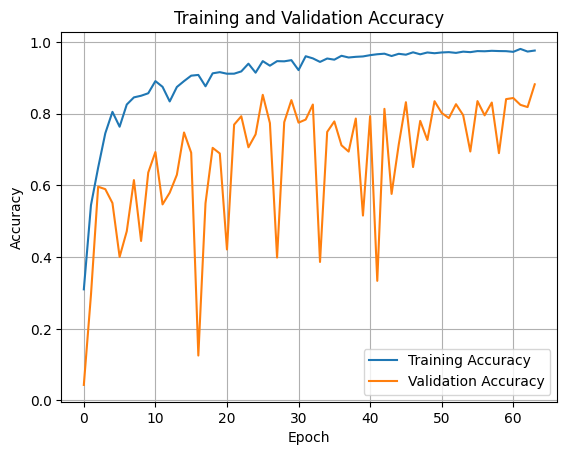

In [32]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

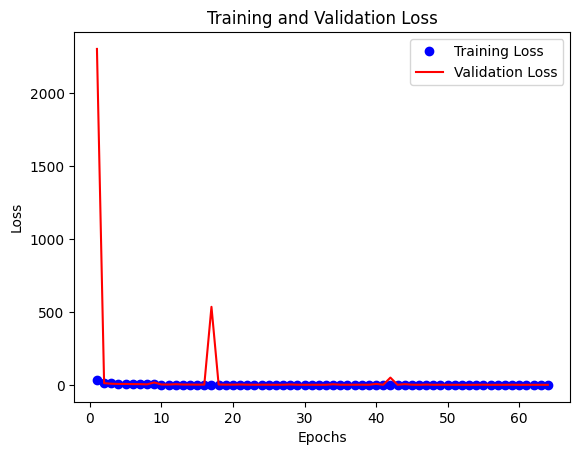

In [33]:
training_loss = history1.history['loss']
validation_loss = history1.history['val_loss']
epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, 'bo', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

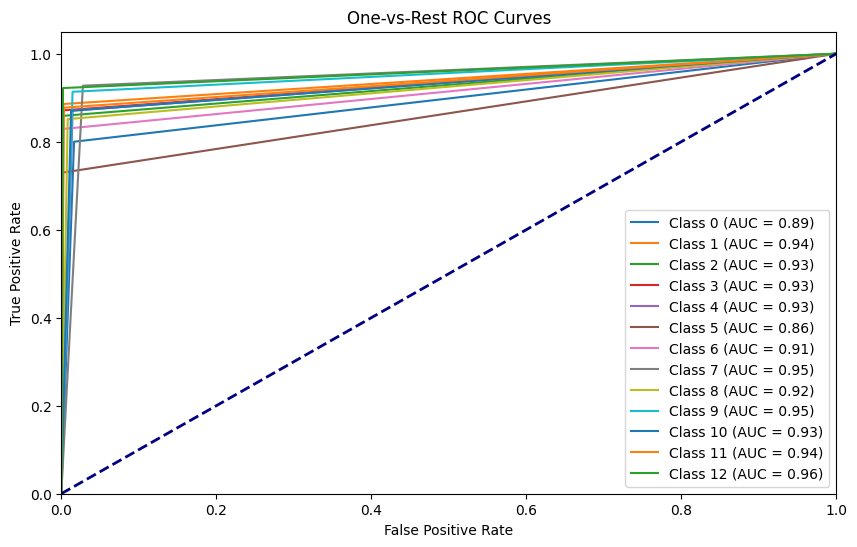

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming y_test are the true labels and y_pred_probs are the predicted probabilities
# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_binary[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
[[122   1   2   1   5   0   0  13   1   3   1   1   0]
 [  1  94   2   2   2   0   0   2   1   0   1   0   0]
 [  2   0  74   0   1   1   0   0   4   1   0   1   1]
 [  3   0   0  90   3   0   0   2   1   0   0   2   0]
 [  8   2   0   0 402   1   3  17   5  10   8   1   0]
 [ 14   1   0   0   6 178   0  10   5   8  10   0   1]
 [  2   0   0   1   6   0 158   5   0   6   8   1   0]
 [  4   1   1   0   5   0   0 386   4  11   1   0   0]
 [  7   0   0   1   3   1   0  15 190   2   1   1   1]
 [  9   0   0   0   4   0   0  19   1 458   6   0   0]
 [  9   1   2   0  11   1   2   8   2   9 347   1   0]
 [  3   2   1   4   5   1   0   3   4   0   1 233   4]
 [  0   1   0   1   1   0   0   3   2   0   0   3 130]]


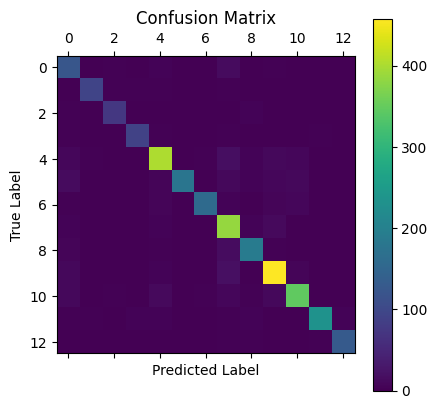

In [35]:
from sklearn.metrics import confusion_matrix

# Get predictions from your model
y_pred2 = model4.predict(x_test)
y_pred_classes = np.argmax(y_pred2, axis=1)  # Convert one-hot to class labels

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print or plot the confusion matrix (various ways to visualize it)
print(cm)

# Example using matplotlib for basic visualization
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()

In [36]:
model4.save('DPN87.h5')

In [ ]:
!zip -r file.zip /kaggle/working


In [ ]:
!ls


In [ ]:
from IPython.display import FileLink
FileLink(r'file.zip')